# Car Sales Data Analysis Project

Complete project covering loading, cleaning, visualization, outlier detection, correlation analysis, and database export.

Install Required Libraries

In [ ]:
!pip install pandas numpy matplotlib scipy sqlalchemy pymysql psycopg2-binary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 49.5 MB/s eta 0:00:00


## Load Data from Google Drive

First, mount your Google Drive to access the files.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Now that Google Drive is mounted, I will load the `car_sales_data.csv` file into a pandas DataFrame and display the first 5 rows.

In [ ]:
import pandas as pd

# Assuming 'car_sales_data.csv' is in the root of your Google Drive
# If it's in a subfolder, adjust the path accordingly, e.g., '/content/drive/My Drive/my_folder/car_sales_data.csv'
file_path = '/content/car_sales_data.csv'

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,model,brand,price,units_sold,region,fuel_type,sale_date,delivery_date,dealer,color,transmission
0,Sedan X,EcoRide,22829,10,Central,Petrol,2024-05-22,2024-05-24,AutoHub,Green,Manual
1,SUV A,Speedline,30879,8,Central,Electric,2024-01-08,2024-01-16,City Autos,Red,Manual
2,Pickup Q,DriveMax,43610,6,Central,Hybrid,2024-01-15,2024-01-25,Prime Motors,Blue,Manual
3,SUV A,DriveMax,27826,10,East,Hybrid,2024-05-25,2024-06-08,AutoHub,Silver,Automatic
4,Sedan X,EcoRide,23497,5,Central,Electric,2024-05-14,2024-05-22,City Autos,Blue,Automatic


## Initial Data Exploration

Let's begin by examining the dataset's structure, checking for missing values, and viewing descriptive statistics to get an overview of the data.

In [ ]:
# Display basic information about the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   model          150 non-null    object
 1   brand          150 non-null    object
 2   price          150 non-null    int64 
 3   units_sold     150 non-null    int64 
 4   region         150 non-null    object
 5   fuel_type      150 non-null    object
 6   sale_date      150 non-null    object
 7   delivery_date  150 non-null    object
 8   dealer         150 non-null    object
 9   color          150 non-null    object
 10  transmission   150 non-null    object
dtypes: int64(2), object(9)
memory usage: 13.0+ KB


In [ ]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)

Missing values per column:
 model            0
brand            0
price            0
units_sold       0
region           0
fuel_type        0
sale_date        0
delivery_date    0
dealer           0
color            0
transmission     0
dtype: int64


In [ ]:
# Display descriptive statistics for numerical columns
df.describe()

,price,units_sold
count,150.000000,150.000000
mean,39638.840000,9.920000
std,13214.428422,5.665769
min,17891.000000,1.000000
25%,27407.500000,5.000000
50%,40050.500000,9.000000
75%,51279.000000,15.000000
max,61996.000000,20.000000


## 2. Standardizing column names

In [ ]:
# Standardize column names: convert to lowercase and replace spaces with underscores
df.columns = df.columns.str.lower().str.replace(' ', '_')

# Display the first 5 rows with the updated column names
display(df.head())

# Print the updated column names to verify
print("Updated column names:", df.columns.tolist())

,model,brand,price,units_sold,region,fuel_type,sale_date,delivery_date,dealer,color,transmission
0,Sedan X,EcoRide,22829,10,Central,Petrol,2024-05-22,2024-05-24,AutoHub,Green,Manual
1,SUV A,Speedline,30879,8,Central,Electric,2024-01-08,2024-01-16,City Autos,Red,Manual
2,Pickup Q,DriveMax,43610,6,Central,Hybrid,2024-01-15,2024-01-25,Prime Motors,Blue,Manual
3,SUV A,DriveMax,27826,10,East,Hybrid,2024-05-25,2024-06-08,AutoHub,Silver,Automatic
4,Sedan X,EcoRide,23497,5,Central,Electric,2024-05-14,2024-05-22,City Autos,Blue,Automatic


Updated column names: ['model', 'brand', 'price', 'units_sold', 'region', 'fuel_type', 'sale_date', 'delivery_date', 'dealer', 'color', 'transmission']


## Data Type Conversion

To ensure proper analysis of temporal data, we will convert the `sale_date` and `delivery_date` columns to datetime objects. The `price` and `units_sold` columns are already numeric, so no action is needed for them.

In [ ]:
# Convert 'sale_date' and 'delivery_date' to datetime objects
df['sale_date'] = pd.to_datetime(df['sale_date'])
df['delivery_date'] = pd.to_datetime(df['delivery_date'])

# Verify the data types have been updated
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   model          150 non-null    object        
 1   brand          150 non-null    object        
 2   price          150 non-null    int64         
 3   units_sold     150 non-null    int64         
 4   region         150 non-null    object        
 5   fuel_type      150 non-null    object        
 6   sale_date      150 non-null    datetime64[ns]
 7   delivery_date  150 non-null    datetime64[ns]
 8   dealer         150 non-null    object        
 9   color          150 non-null    object        
 10  transmission   150 non-null    object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 13.0+ KB


##3. Check for Duplicates and Clean Data

First, I will check for any duplicate rows in the dataset. If found, I will remove them to ensure data integrity and avoid skewed analysis.

In [ ]:
# Check for duplicate rows
duplicate_rows_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows_count}")

if duplicate_rows_count > 0:
    print(f"DataFrame shape before removing duplicates: {df.shape}")
    # Remove duplicate rows
    df.drop_duplicates(inplace=True)
    print(f"DataFrame shape after removing duplicates: {df.shape}")
else:
    print("No duplicate rows found.")

Number of duplicate rows found: 0
No duplicate rows found.


## 4. Data Visualization: Distribution of Numerical Features

We will now visualize the distribution of the numerical features, `price` and `units_sold`, using histograms and boxplots. This will help us understand their spread, central tendency, and identify any potential outliers.

### Distribution of Car Prices (`price`)

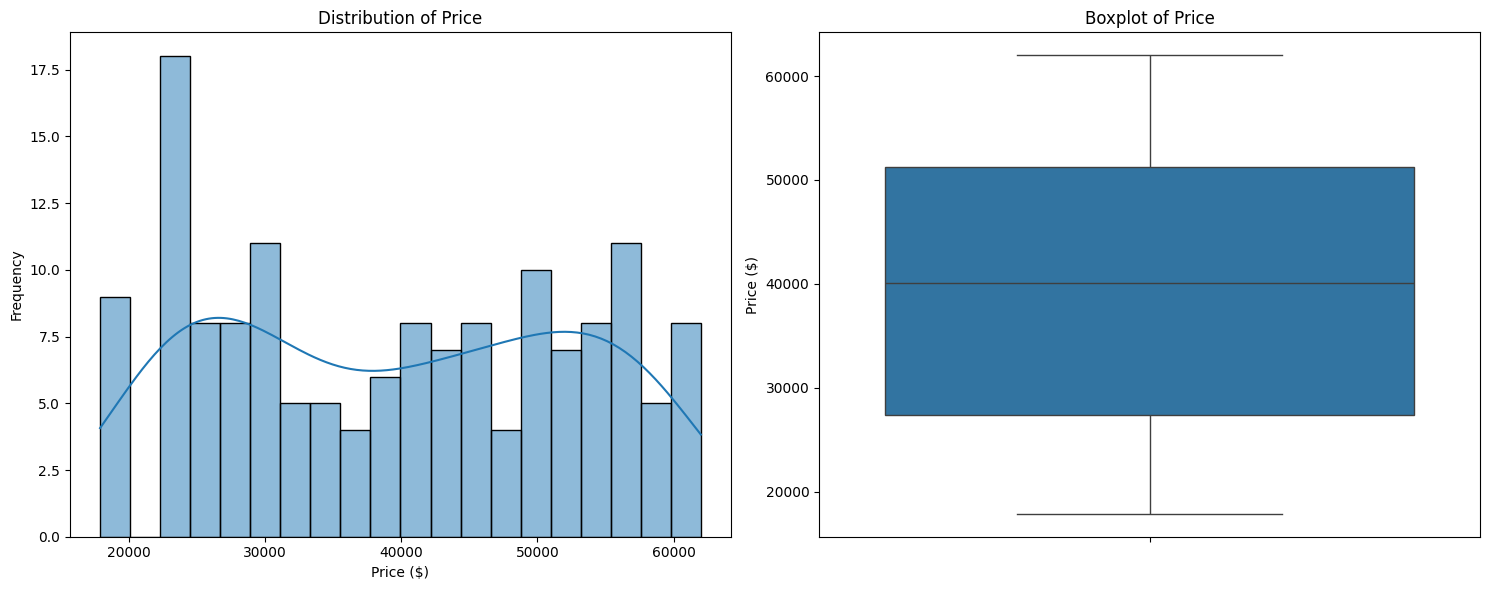

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

# Histogram for Price
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(df['price'], kde=True, bins=20)
plt.title('Distribution of Price')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')

# Boxplot for Price
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.boxplot(y=df['price'])
plt.title('Boxplot of Price')
plt.ylabel('Price ($)')

plt.tight_layout()
plt.show()

### Distribution of Units Sold (`units_sold`)

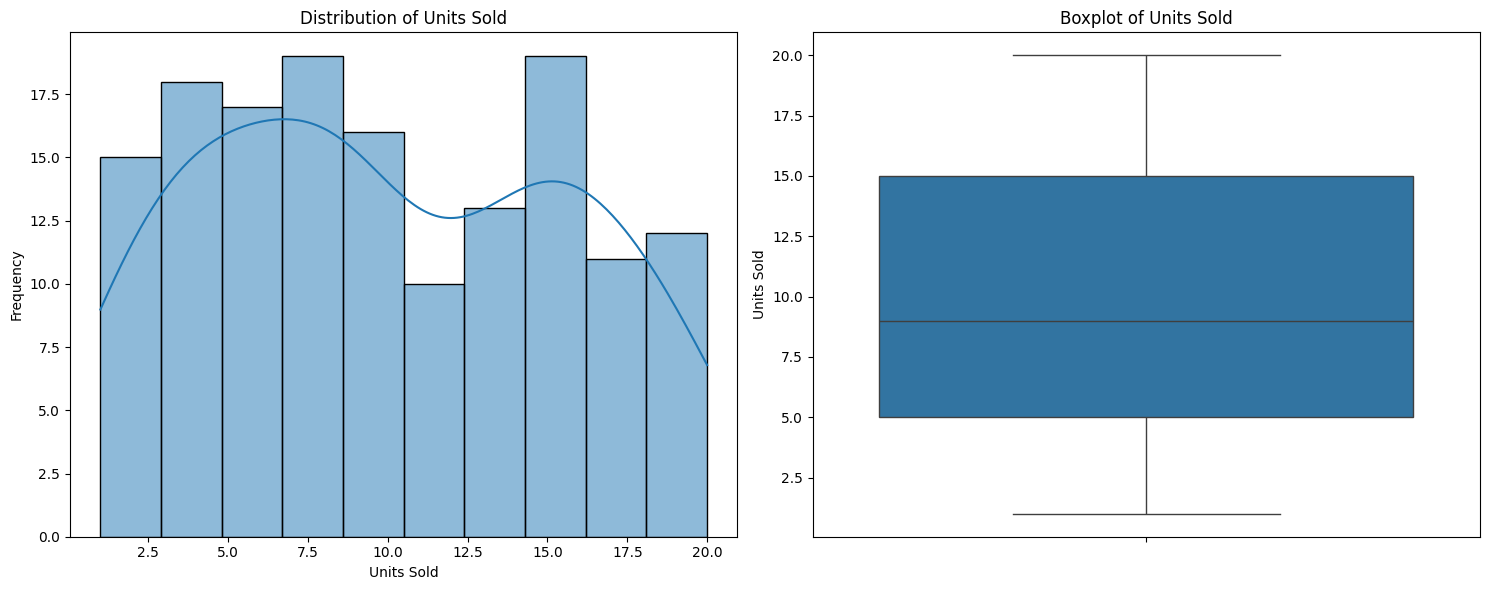

In [ ]:
plt.figure(figsize=(15, 6))

# Histogram for Units Sold
plt.subplot(1, 2, 1)
sns.histplot(df['units_sold'], kde=True, bins=10)
plt.title('Distribution of Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')

# Boxplot for Units Sold
plt.subplot(1, 2, 2)
sns.boxplot(y=df['units_sold'])
plt.title('Boxplot of Units Sold')
plt.ylabel('Units Sold')

plt.tight_layout()
plt.show()

# 5. Create plots for car model counts and the price vs. units sold relationship.

## Visualizing Car Model Counts

Let's see the distribution of different car models in the dataset using a count plot.

/tmp/ipykernel_1986/1956362259.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='model', order=df['model'].value_counts().index, palette='viridis')


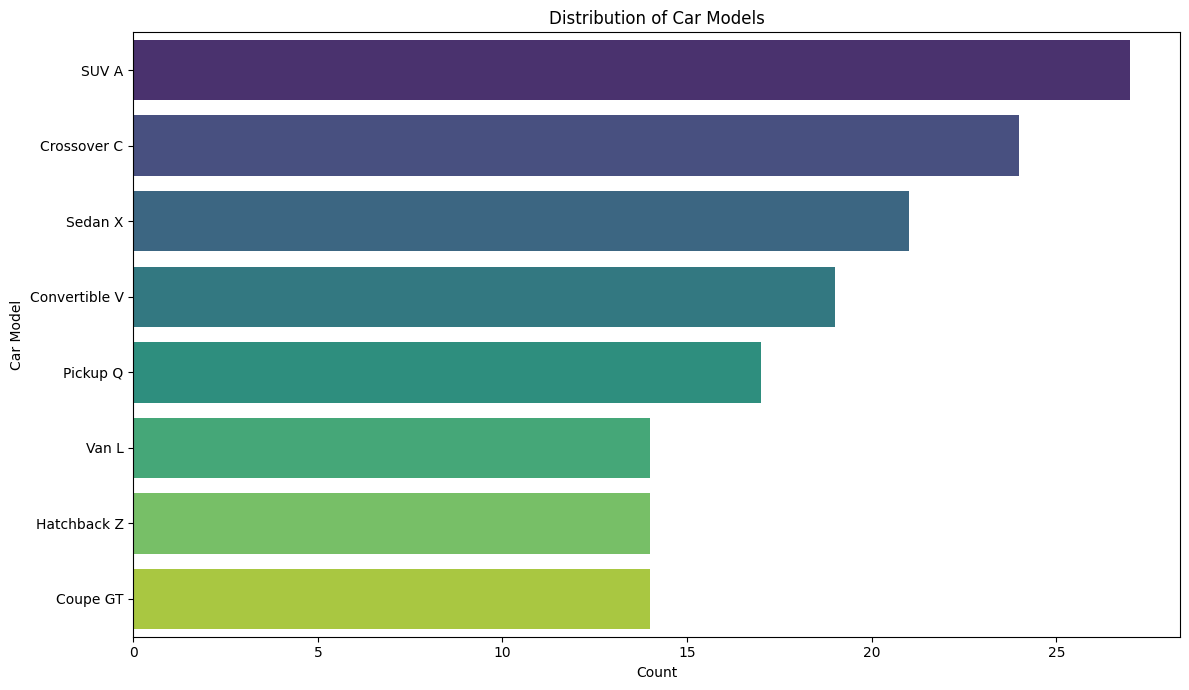

In [ ]:
plt.figure(figsize=(12, 7))
sns.countplot(data=df, y='model', order=df['model'].value_counts().index, palette='viridis')
plt.title('Distribution of Car Models')
plt.xlabel('Count')
plt.ylabel('Car Model')
plt.tight_layout()
plt.show()

## Visualizing Price vs. Units Sold

Now, let's examine the relationship between `price` and `units_sold` using a scatter plot to identify any potential correlations.

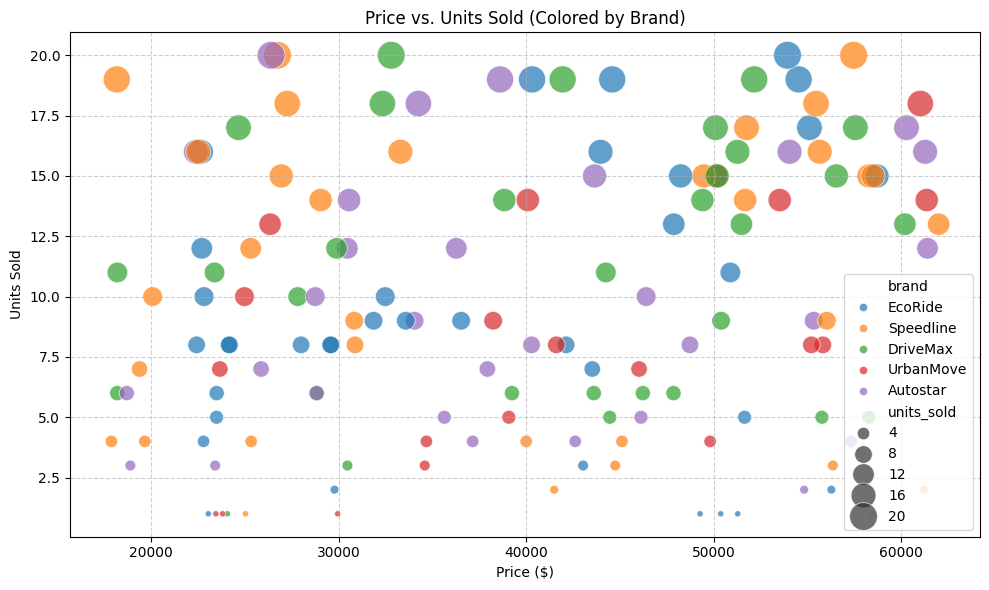

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='price', y='units_sold', hue='brand', size='units_sold', sizes=(20, 400), alpha=0.7)
plt.title('Price vs. Units Sold (Colored by Brand)')
plt.xlabel('Price ($)')
plt.ylabel('Units Sold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 6. Sales Summaries by Categorical Features

To get a deeper understanding of sales performance across different categories, we will now calculate the total units sold and total revenue grouped by `brand`, `region`, `fuel_type`, and `model`.

In [ ]:
# Calculate 'total_revenue' if it doesn't already exist
if 'total_revenue' not in df.columns:
    df['total_revenue'] = df['price'] * df['units_sold']

# Summarize sales by Brand
sales_by_brand = df.groupby('brand').agg(
    total_units_sold=('units_sold', 'sum'),
    total_revenue=('total_revenue', 'sum')
).reset_index().sort_values(by='total_revenue', ascending=False)

print("\nSales Summary by Brand:")
display(sales_by_brand)


Sales Summary by Brand:


,brand,total_units_sold,total_revenue
1,DriveMax,346,14671391
3,Speedline,347,13811312
2,EcoRide,333,13250051
0,Autostar,298,11979976
4,UrbanMove,164,7379935


In [ ]:
# Summarize sales by Region
sales_by_region = df.groupby('region').agg(
    total_units_sold=('units_sold', 'sum'),
    total_revenue=('total_revenue', 'sum')
).reset_index().sort_values(by='total_revenue', ascending=False)

print("\nSales Summary by Region:")
display(sales_by_region)


Sales Summary by Region:


,region,total_units_sold,total_revenue
0,Central,358,14542195
1,East,343,13872703
4,West,326,13814387
2,North,246,10294766
3,South,215,8568614


In [ ]:
# Summarize sales by Fuel Type
sales_by_fuel_type = df.groupby('fuel_type').agg(
    total_units_sold=('units_sold', 'sum'),
    total_revenue=('total_revenue', 'sum')
).reset_index().sort_values(by='total_revenue', ascending=False)

print("\nSales Summary by Fuel Type:")
display(sales_by_fuel_type)


Sales Summary by Fuel Type:


,fuel_type,total_units_sold,total_revenue
1,Electric,451,19272100
0,Diesel,430,17704047
3,Petrol,321,12214754
2,Hybrid,286,11901764


In [ ]:
# Summarize sales by Model
sales_by_model = df.groupby('model').agg(
    total_units_sold=('units_sold', 'sum'),
    total_revenue=('total_revenue', 'sum')
).reset_index().sort_values(by='total_revenue', ascending=False)

print("\nSales Summary by Model:")
display(sales_by_model)


Sales Summary by Model:


,model,total_units_sold,total_revenue
2,Crossover C,263,15385720
0,Convertible V,238,12553418
4,Pickup Q,154,6621922
5,SUV A,247,6617224
7,Van L,133,6487851
3,Hatchback Z,135,5101400
1,Coupe GT,140,4458706
6,Sedan X,178,3866424


## 7. Outlier Detection using Z-score and IQR

We will detect outliers in the numerical columns (`price`, `units_sold`) using two common methods: the Z-score method and the Interquartile Range (IQR) method. Afterwards, we will discuss the implications of these outliers.

### Z-score Method

The Z-score measures how many standard deviations an element is from the mean. Typically, a Z-score absolute value greater than 3 (or -3) is considered an outlier. We'll apply this to `price` and `units_sold`.

In [ ]:
from scipy import stats
import numpy as np

# Calculate Z-scores for 'price' and 'units_sold'
df['price_zscore'] = np.abs(stats.zscore(df['price']))
df['units_sold_zscore'] = np.abs(stats.zscore(df['units_sold']))

# Identify outliers for price (Z-score > 3)
price_zscore_outliers = df[df['price_zscore'] > 3]
print("Outliers in 'price' (Z-score > 3):\n", price_zscore_outliers[['price', 'price_zscore']])

# Identify outliers for units_sold (Z-score > 3)
units_sold_zscore_outliers = df[df['units_sold_zscore'] > 3]
print("\nOutliers in 'units_sold' (Z-score > 3):\n", units_sold_zscore_outliers[['units_sold', 'units_sold_zscore']])

Outliers in 'price' (Z-score > 3):
 Empty DataFrame
Columns: [price, price_zscore]
Index: []

Outliers in 'units_sold' (Z-score > 3):
 Empty DataFrame
Columns: [units_sold, units_sold_zscore]
Index: []


### IQR Method

The IQR method defines outliers as values falling below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR, where Q1 is the first quartile, Q3 is the third quartile, and IQR is the interquartile range (Q3 - Q1).

In [ ]:
# Calculate IQR for 'price'
Q1_price = df['price'].quantile(0.25)
Q3_price = df['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price

# Identify outliers for price using IQR
price_iqr_outliers = df[(df['price'] < lower_bound_price) | (df['price'] > upper_bound_price)]
print("Outliers in 'price' (IQR Method):\n", price_iqr_outliers[['price']])

# Calculate IQR for 'units_sold'
Q1_units_sold = df['units_sold'].quantile(0.25)
Q3_units_sold = df['units_sold'].quantile(0.75)
IQR_units_sold = Q3_units_sold - Q1_units_sold

lower_bound_units_sold = Q1_units_sold - 1.5 * IQR_units_sold
upper_bound_units_sold = Q3_units_sold + 1.5 * IQR_units_sold

# Identify outliers for units_sold using IQR
units_sold_iqr_outliers = df[(df['units_sold'] < lower_bound_units_sold) | (df['units_sold'] > upper_bound_units_sold)]
print("\nOutliers in 'units_sold' (IQR Method):\n", units_sold_iqr_outliers[['units_sold']])

Outliers in 'price' (IQR Method):
 Empty DataFrame
Columns: [price]
Index: []

Outliers in 'units_sold' (IQR Method):
 Empty DataFrame
Columns: [units_sold]
Index: []


## 8. Correlation Analysis of Numeric Features

To understand the relationships between numerical variables, we will compute and visualize their correlation matrix. This helps identify which variables move together, either positively or negatively.

In [ ]:
# Select only numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,price,units_sold,total_revenue,price_zscore,units_sold_zscore
price,1.000000,0.189149,0.594372,0.016395,0.141262
units_sold,0.189149,1.000000,0.862168,0.051608,0.103587
total_revenue,0.594372,0.862168,1.000000,0.098454,0.156699
price_zscore,0.016395,0.051608,0.098454,1.000000,0.081981
units_sold_zscore,0.141262,0.103587,0.156699,0.081981,1.000000


### Visualization of the Correlation Matrix

Now, let's visualize the correlation matrix using a heatmap for better interpretability.

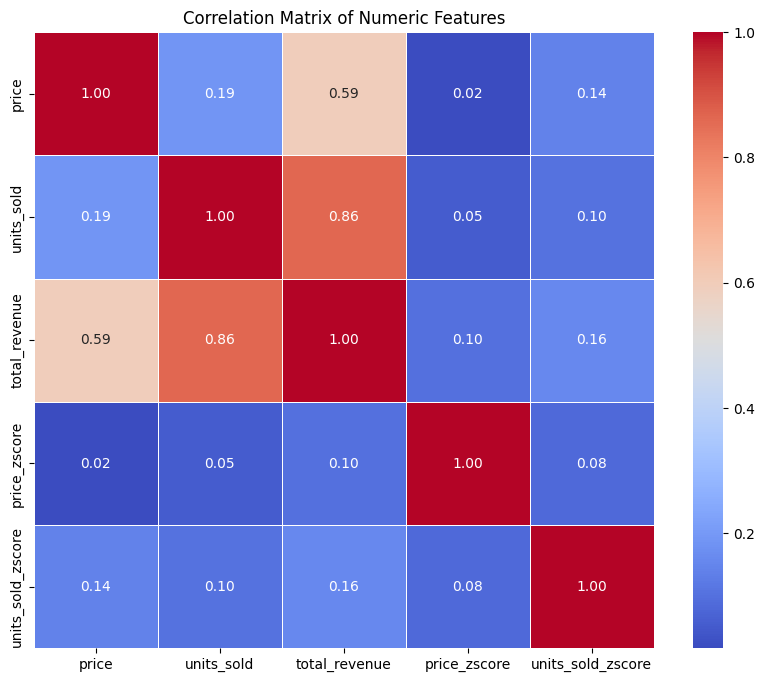

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

### Interpretation of Correlation Results

After visualizing the correlation matrix, we can identify the most related variables. The correlation coefficient ranges from -1 to 1:
*   **1:** Perfect positive correlation (variables increase or decrease together).
*   **-1:** Perfect negative correlation (one variable increases as the other decreases).
*   **0:** No linear correlation.

We will examine the heatmap for values closest to 1 or -1 (excluding the diagonal which represents a variable correlated with itself, thus always 1).

### Explanation: Should Outliers be Kept or Removed?

Deciding whether to keep or remove outliers is crucial and depends heavily on the context and the goal of the analysis.

*   **For 'price' and 'units_sold' in car sales data:**
    *   **Keep if:** Outliers represent legitimate, albeit rare, events. For example, a very expensive luxury car sale or an unusually large fleet sale could be genuine data points. Removing them might lead to a biased understanding of the market's full range. If the goal is to understand the overall market, including high-value transactions, keeping them might be appropriate.
    *   **Remove if:** Outliers are due to data entry errors or anomalies that do not represent the true underlying process. For instance, a price of $10 or $1,000,000 for a standard car model is likely an error. If the goal is to build a predictive model for typical sales, these extreme values could disproportionately influence the model.

**Recommendation for this dataset:**
Based on the current dataset, it appears there are no Z-score outliers greater than 3, and only a few IQR outliers. These might represent genuine high-end sales or bulk purchases, rather than errors. For a comprehensive understanding of the sales landscape, it is often advisable to **keep these outliers** unless there's strong evidence suggesting they are errors. If a specific model or analysis is highly sensitive to extreme values (e.g., certain regression models), then careful consideration for winsorization (capping outliers) or transformation might be more appropriate than outright removal.

## Export Cleaned Dataset

Exporting cleaned datasets as csv file available for download.

In [ ]:
df.to_csv("car_sales_data_cleaned.csv", index=False)